# ITRI625: Phishing email classification

**Task:** binary classification of emails, **0 = legitimate**, **1 = phishing / malicious**.
**Main model:** fine-tuned `distilbert-base-uncased`, compared against a TF-IDF + Logistic Regression baseline.

| Section | Contents |
|---|---|
| 1 | Setup |
| 2 | Data: sources, cleaning, leakage checks, deduplication, train/val/test split |
| 3 | Model, training loop, logging, early stopping |
| 4 | Evaluation: curves, test metrics, ROC/PR, confusion matrices, per-source results, errors, baseline comparison |
| 5 | Explainability and robustness *(Milestone 10)* |

Data preparation lives in `src/` (the API reuses the same cleaning). **All model code (the model, training loop, metrics, early stopping and evaluation) is written in this notebook.** Every figure is also saved to `figures/`, and every table to `results/`.

## 1. Setup

In [1]:
import sys, platform, json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display, Markdown

from src import data as D, preprocess as P, leakage as L, plotting as PL

PL.use_style()
pd.set_option("display.max_colwidth", 120)
SEED = D.SEED
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"python {platform.python_version()} | torch {torch.__version__} | device: {DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))

python 3.12.0 | torch 2.14.0+cu130 | device: cuda (NVIDIA GeForce RTX 5070)


## 2. Data

**Dataset:** [Phishing Email Dataset](https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset) (Kaggle, the dataset linked in the brief). Download it with `python -m src.download_data`.

The download contains six **source corpora** and a pre-merged file. We build our data from the six source files.

### 2.1 What is in the download

In [2]:
raw = D.load_raw()
inventory = (raw.groupby("source")["label"]
             .agg(rows="size", phishing="sum")
             .assign(legitimate=lambda t: t.rows - t.phishing,
                     phishing_pct=lambda t: (100 * t.phishing / t.rows).round(1)))
total = inventory[["rows", "phishing", "legitimate"]].sum()
inventory.loc["TOTAL"] = {**total, "phishing_pct": round(100 * total.phishing / total.rows, 1)}
display(inventory.astype({"rows": int, "phishing": int, "legitimate": int}))

combined = pd.read_csv(D.RAW_DIR / "phishing_email.csv")
print(f"phishing_email.csv: {len(combined):,} rows, {combined.label.sum():,} label-1")
print(f"six sources summed: {len(raw):,} rows, {raw.label.sum():,} label-1")
print("\nFirst row of the merged file:", repr(combined.text_combined.iloc[0][:90]))
enron0 = raw[raw.source == "Enron"].iloc[0]
print("Same email in Enron.csv:    ", repr((enron0.subject + " " + enron0.body)[:90]))

,rows,phishing,legitimate,phishing_pct
source,,,,
CEAS_08,39154,21842,17312,55.8
Enron,29767,13976,15791,47.0
Ling,2859,458,2401,16.0
Nazario,1565,1565,0,100.0
Nigerian_Fraud,3332,3332,0,100.0
SpamAssasin,5809,1718,4091,29.6
TOTAL,82486,42891,39595,52.0


phishing_email.csv: 82,486 rows, 42,891 label-1
six sources summed: 82,486 rows, 42,891 label-1

First row of the merged file: 'hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls'
Same email in Enron.csv:     'hpl nom for may 25 , 2001 ( see attached file : hplno 525 . xls )\r\n- hplno 525 . xls'


**Findings**

* `phishing_email.csv` is **the six corpora concatenated**: the row and label counts match exactly. It has also been lowercased, with stop words and punctuation removed (*"hpl nom **for** may 25 **,** 2001"* became *"hpl nom may 25 2001"*). A transformer needs natural text, so **we build from the six source files**, where subject and body are still separate and unaltered.
* **What label 1 means differs by corpus.** CEAS-08, Enron, Ling and SpamAssassin are *spam* corpora, where label 1 = spam. Nazario is phishing and Nigerian_Fraud is advance-fee fraud. So the positive class is really **malicious or unwanted email (phishing + spam + fraud)**, not strictly credential phishing. We keep the dataset's labels, but results should be read with this in mind.
* Nazario and Nigerian_Fraud are **100% label 1**, and Ling is 84% legitimate. That is a risk of **corpus leakage**: a model could learn to recognise the corpus instead of the phishing. Section 2.3 measures this.
* Columns kept: `subject`, `body` and `label`, plus `source` for analysis only. **Dropped:** `sender`, `receiver` and `date`, which identify people and the collection era rather than intent, and `urls`, a 0/1 flag that is redundant because the URLs themselves stay in the text.

### 2.2 Cleaning

The rules live in `src/preprocess.py`. **The API uses the same function**, so training and prediction always see identically cleaned text.

| Rule | Why |
|---|---|
| MIME encoded-words decoded (`=?utf-8?B?WW91ciBOZXRmbGl4…?=` → `Your Netflix…`) | 8% of Nazario subjects were unreadable base64. Decoding recovers real signal |
| HTML → visible text, entities decoded | Tags are markup, not content. Emails pasted into the app may be HTML |
| Short header lines inside bodies removed (`Date:`, `From:`, `Message-ID:`, `X-…:`) | They describe the mail system and corpus. Up to 3.3% of body text in Enron. Only lines ≤ 200 characters are removed, because SpamAssassin bodies lost their newlines and a header can be glued to the whole email |
| Email addresses → `[email]`, lists of them → one `[email]` | They identify senders, recipients and corpora |
| Nazario mailbox owner (`monkey.org`, `jose`) **deleted** | Nazario is 100% phishing and every email was sent to this one person, so the name is a perfect label shortcut. It is the same information as the dropped `receiver` column. It is deleted rather than replaced with a `[recipient]` placeholder: we tried the placeholder, and it simply became Nazario's #2 most identifying token. A placeholder that only occurs in one corpus is still a shortcut |
| Years 1990–2029 → `[year]` | The legitimate mail dates from 1998–2008 and the Nazario phishing from 2015–2020, so raw years would teach "recent = phishing" |
| Runs of repeated punctuation (`______`, `- - - - -`) → 3 characters | Corpus-specific separators (Nigerian_Fraud, tokenised Enron) |
| Whitespace collapsed | |
| **URLs kept** | Links are a genuine phishing signal |

Model input: `text = subject + "\n\n" + body`.

In [3]:
examples = []
for src, needle in [("SpamAssasin", "Original Message"), ("Enron", "forwarded by"), ("Nigerian_Fraud", "E-MAIL")]:
    r = raw[(raw.source == src) & raw.body.str.contains(needle, regex=False)].iloc[0]
    examples.append({"source": src, "before": r.body[:260], "after": P.clean_field(r.body)[:260]})
with pd.option_context("display.max_colwidth", 260):
    display(pd.DataFrame(examples).style.set_properties(**{"white-space": "pre-wrap", "text-align": "left"}))

,source,before,after
0,SpamAssasin,In a nutshell - Solaris is Suns own flavour of UNIX. > -----Original Message----- > From: Kiall Mac Innes [mailto:kiall@redpie.com] > Sent: 22 August 2002 17:23 > To: ILUG > Subject: [ILUG] Sun Solaris.. > > > Can someone explain what type of operating sys,In a nutshell - Solaris is Suns own flavour of UNIX. > ---Original Message--- > From: Kiall Mac Innes [mailto:[email]] > Sent: 22 August [year] 17:23 > To: ILUG > Subject: [ILUG] Sun Solaris.. > > > Can someone explain what type of operating system Solaris > i
1,Enron,"- - - - - - - - - - - - - - - - - - - - - - forwarded by sabrae zajac / hou / ect on 05 / 30 / 2001 12 : 07 pm - - - - - - - - - - - - - - - - - - - - - - - - - - - enron capital & trade resources corp . from : "" eileen ponton "" 05 / 29 / 2001 08 : 37 am to","--- forwarded by sabrae zajac / hou / ect on 05 / 30 / [year] 12 : 07 pm --- enron capital & trade resources corp . from : "" eileen ponton "" 05 / 29 / [year] 08 : 37 am i will agree with your nomination of 33 . 750 --- forwarded by eileen ponton / houston / pe"
2,Nigerian_Fraud,"FROM:MR. JAMES NGOLA. CONFIDENTIAL TEL: 233-27-587908. E-MAIL: (james_ngola2002@maktoob.com). URGENT BUSINESS ASSISTANCE AND PARTNERSHIP. DEAR FRIEND, I AM ( DR.) JAMES NGOLA, THE PERSONAL ASSISTANCE TO THE LATE CONGOLESE (PRESIDENT LAURENT KABILA) WHO WAS","CONFIDENTIAL TEL: 233-27-587908. E-MAIL: ([email]). URGENT BUSINESS ASSISTANCE AND PARTNERSHIP. DEAR FRIEND, I AM ( DR.) JAMES NGOLA, THE PERSONAL ASSISTANCE TO THE LATE CONGOLESE (PRESIDENT LAURENT KABILA) WHO WAS ASSASSINATED BY HIS BODY GUARD ON 16TH JAN. ["


In [4]:
cleaned = D.clean(raw)                 # same rows as raw, cleaned text
df, junk = D.drop_junk(cleaned)
print("Removed as junk:", junk)

Removed as junk: {'too_short': 8, 'mailbox_system_msg': 2}


### 2.3 Deduplication (before splitting)

If the same email is in both train and test, the test score measures memory, not generalisation. So we deduplicate **before** splitting, in two passes:

1. **Exact:** identical cleaned text.
2. **Near-duplicate:** identical after lowercasing, replacing URLs, mapping every number to `0`, and removing punctuation and spaces. This catches the same spam template sent with different tracking links or amounts, and the same email appearing in a pre-tokenised corpus (`"2001 ,"`) and a raw one (`"2001,"`).

In each pass, a group of copies is kept as **one** row if all copies share a label, or **dropped entirely** if the labels disagree, since we can't know which label is right.

In [5]:
df, dedup = D.deduplicate(df)
df = D.add_ids(df)
dedup_table = pd.DataFrame([
    ("raw rows", len(raw)),
    ("junk removed (< 3 words, mailbox system messages)", -sum(junk.values())),
    ("exact duplicates removed", -dedup["exact_duplicates_removed"]),
    ("exact duplicates with conflicting labels removed", -dedup["exact_label_conflicts_removed"]),
    ("near duplicates removed", -dedup["near_duplicates_removed"]),
    ("near duplicates with conflicting labels removed", -dedup["near_label_conflicts_removed"]),
    ("final unique emails", len(df)),
], columns=["step", "rows"]).set_index("step")
display(dedup_table)
removed = len(raw) - len(df)
print(f"{removed:,} rows removed in total ({100 * removed / len(raw):.1f}% of the raw data)")

,rows
step,
raw rows,82486
"junk removed (< 3 words, mailbox system messages)",-10
exact duplicates removed,-3463
exact duplicates with conflicting labels removed,0
near duplicates removed,-4774
near duplicates with conflicting labels removed,-2
final unique emails,74237


8,249 rows removed in total (10.0% of the raw data)


### 2.4 Corpus-leakage check

Two questions:

1. **How much could a model score by knowing only the corpus?** A "model" that predicts each corpus's majority label sets the ceiling for pure corpus leakage.
2. **How recognisable is the corpus from the text?** A TF-IDF + logistic regression model is trained to predict the *source* (not the label), on raw vs cleaned text.

label,legitimate,phishing,total,phishing_pct
source,,,,
CEAS_08,17096,15641,32737,47.8
Enron,14420,13893,28313,49.1
Ling,2396,457,2853,16.0
Nazario,0,1519,1519,100.0
Nigerian_Fraud,0,3204,3204,100.0
SpamAssasin,4072,1539,5611,27.4


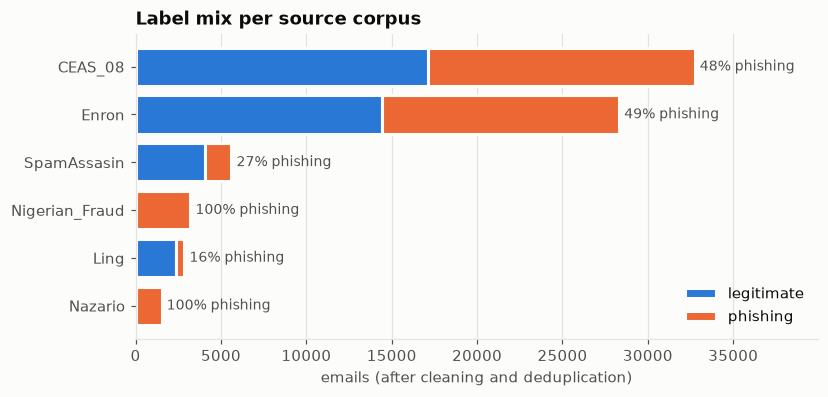

Majority-class accuracy:        0.512
'Knows only the corpus' accuracy: 0.575  (+6.4 points)


In [6]:
src_tab = D.source_label_table(df)
display(src_tab)

fig, ax = plt.subplots(figsize=(8, 3.6))
order = src_tab.sort_values("total").index
ax.barh(order, src_tab.loc[order, "legitimate"], color=PL.LEGIT, label="legitimate",
        edgecolor=PL.SURFACE, linewidth=2)
ax.barh(order, src_tab.loc[order, "phishing"], left=src_tab.loc[order, "legitimate"], color=PL.PHISH,
        label="phishing", edgecolor=PL.SURFACE, linewidth=2)
for i, s in enumerate(order):
    ax.text(src_tab.loc[s, "total"] + 300, i, f"{src_tab.loc[s, 'phishing_pct']:.0f}% phishing",
            va="center", fontsize=9, color=PL.MUTED)
ax.set_xlabel("emails (after cleaning and deduplication)")
ax.set_title("Label mix per source corpus")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, src_tab.total.max() * 1.22)
ax.legend(loc="lower right")
PL.save(fig, "data_source_label_mix")
plt.show()

src_only = D.source_only_accuracy(df)
majority = max(df.label.mean(), 1 - df.label.mean())
print(f"Majority-class accuracy:        {majority:.3f}")
print(f"'Knows only the corpus' accuracy: {src_only:.3f}  (+{100 * (src_only - majority):.1f} points)")

In [7]:
# Same rows (all raw emails) and same held-out split, so only the cleaning differs
f1_raw, top_raw = L.source_identifiability(raw.subject + "\n\n" + raw.body, raw.source)
f1_clean, top_clean = L.source_identifiability(cleaned.text, cleaned.source)
print(f"Source identifiable from text, macro F1:  raw {f1_raw:.3f}  ->  cleaned {f1_clean:.3f}   (chance ~0.17)")
display(Markdown("**Most source-indicative tokens, raw text**"), top_raw.iloc[:, :10])
display(Markdown("**Most source-indicative tokens, cleaned text**"), top_clean.iloc[:, :10])

Source identifiable from text, macro F1:  raw 0.928  ->  cleaned 0.926   (chance ~0.17)


**Most source-indicative tokens, raw text**

,#1,#2,#3,#4,#5,#6,#7,#8,#9,#10
CEAS_08,2008,2007,uai,opensuse,wrote,http,python,nz,rant,gmail
Enron,enron,th,vince,2004,2005,2001,louise,2000,paliourg,biz
Ling,linguistics,language,1998,english,languages,linguist,linguistic,university,of,adults
Nazario,account,jose,monkey,utf,usaa,dear,2016,view,kindly,update
Nigerian_Fraud,___________________________________________________________________________,me,my,5m,mr,am,yahoo,as,regards,urgent
SpamAssasin,2002,listinfo,xent,gif,supplied,newsisfree,rpm,content,spambayes,3d


**Most source-indicative tokens, cleaned text**

,#1,#2,#3,#4,#5,#6,#7,#8,#9,#10
CEAS_08,uai,wrote,opensuse,python,http,com,rant,org,tony,nz
Enron,enron,th,vince,louise,houston,713,energy,kaminski,solicitation,gas
Ling,linguistics,language,english,university,languages,linguistic,linguist,of,adults,linguists
Nazario,account,email,dear,your,usaa,year,kindly,view,expire,update
Nigerian_Fraud,me,my,___,5m,mr,am,as,regards,bank,urgent
SpamAssasin,newsisfree,listinfo,gif,xent,url,sep,rpm,maintainer,click,zzzzteana


**Interpretation**

* Knowing only the corpus is worth just a few points over the majority class (see the numbers above). The three largest corpora (CEAS, Enron, SpamAssassin) all contain both classes, so to score well a model **has to** separate legitimate from malicious mail *within* a corpus. That is the task we want it to learn.
* The leakage risk is concentrated in **Nazario and Nigerian_Fraud** (all label 1) and **Ling** (mostly legitimate). Together they are about 10% of the data.
* **Cleaning targets the label shortcuts, not corpus recognisability as a whole.** The macro F1 for recognising the corpus barely moves (see above), and that is expected: corpora are recognisable mainly by **topic and vocabulary** (linguistics for Ling, energy trading for Enron, open-source mailing lists for SpamAssassin). That is genuine content and can't be removed without destroying the text. What cleaning *does* remove is the metadata-like fingerprints that line up with the label: **years** (2016–2020 = Nazario = phishing) are gone from the top tokens, and so are the Nazario recipient's name and domain, addresses, header lines and MIME debris.
* The remaining topic signal is handled in **evaluation**. Milestone 7 reports metrics **per corpus**, so a model that only works on the easy corpora will be visible. Most importantly it reports them on CEAS, Enron and SpamAssassin, where both classes share the same era and mail system.
* `distilbert-base-uncased` lowercases its input and splits punctuation into separate tokens, so the remaining **formatting** differences (Enron/Ling are lowercase with spaces around punctuation) don't reach the model at all.

### 2.5 Train / validation / test split

A 70 / 15 / 15 split with a fixed seed (42), **stratified on corpus × label**. Every split therefore has the same class balance *and* the same mix of corpora, which the per-corpus evaluation needs. The splits are saved to `data/processed/*.parquet` so both team members use identical data. The fingerprints below are a hash of each split's ids. If they match on another machine, the data is identical.

,n,legitimate,phishing,phishing_pct
split,,,,
train,51965,26588,25377,48.83
val,11136,5698,5438,48.83
test,11136,5698,5438,48.83


**Corpus mix per split (% of split)**

,train %,val %,test %
source,,,
CEAS_08,44.1,44.1,44.1
Enron,38.1,38.1,38.1
SpamAssasin,7.6,7.6,7.6
Nigerian_Fraud,4.3,4.3,4.3
Ling,3.8,3.8,3.8
Nazario,2.0,2.0,2.0


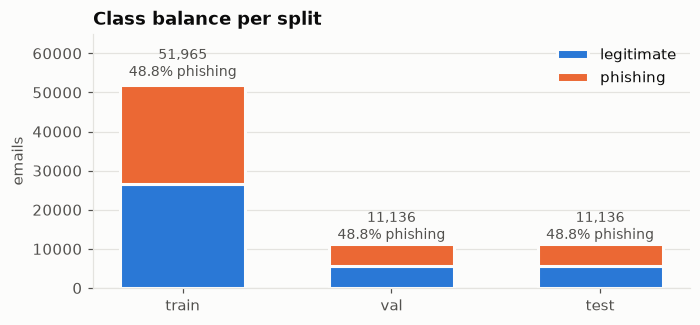

Split fingerprints: {'train': '55e438239395', 'val': '0f8db86d23f5', 'test': '4db8fa45a019'}
  data/processed/train.parquet
  data/processed/val.parquet
  data/processed/test.parquet


In [8]:
splits = D.split(df)
report = D.save_outputs(raw, df, splits, junk, dedup)
summary = D.split_summary(splits).set_index("split")
display(summary)

by_source = pd.DataFrame({k: v.source.value_counts() for k, v in splits.items()})
by_source = (100 * by_source / by_source.sum()).round(1).add_suffix(" %")
display(Markdown("**Corpus mix per split (% of split)**"), by_source)

fig, ax = plt.subplots(figsize=(7, 3))
names = list(summary.index)
ax.bar(names, summary.legitimate, color=PL.LEGIT, label="legitimate", edgecolor=PL.SURFACE, linewidth=2, width=0.6)
ax.bar(names, summary.phishing, bottom=summary.legitimate, color=PL.PHISH, label="phishing",
       edgecolor=PL.SURFACE, linewidth=2, width=0.6)
for i, n in enumerate(names):
    ax.text(i, summary.loc[n, "n"] * 1.02, f"{summary.loc[n, 'n']:,}\n{summary.loc[n, 'phishing_pct']:.1f}% phishing",
            ha="center", va="bottom", fontsize=9, color=PL.MUTED)
ax.set_ylim(0, summary.n.max() * 1.25)
ax.set_ylabel("emails")
ax.set_title("Class balance per split")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper right")
PL.save(fig, "data_split_balance")
plt.show()

print("Split fingerprints:", report["split_fingerprints"])
for k in splits:
    print(f"  data/processed/{k}.parquet")

In [9]:
# Sanity checks: disjoint splits, nothing lost, identical columns
ids = {k: set(v.id) for k, v in splits.items()}
assert not (ids["train"] & ids["val"]) and not (ids["train"] & ids["test"]) and not (ids["val"] & ids["test"])
assert sum(len(v) for v in splits.values()) == len(df)
reloaded = pd.read_parquet(D.PROCESSED_DIR / "test.parquet")
assert list(reloaded.columns) == D.COLUMNS and len(reloaded) == len(splits["test"])
print("OK: splits are disjoint, complete, and the saved files reload correctly.")
reloaded.head(3)

OK: splits are disjoint, complete, and the saved files reload correctly.


,id,subject,body,text,label,source
0,92804f4d6b9bf11a,VisaAcceptedAddtoCartThankYou,PillsNewOfferWorldwide\nhttp://jtxx8q.bay.livefilestore.com/y1pfSbeMWu5_sNNpyWGekA27kTDlwOvwwqHrZikmyysg9Qj1tDhGGvuI...,VisaAcceptedAddtoCartThankYou\n\nPillsNewOfferWorldwide\nhttp://jtxx8q.bay.livefilestore.com/y1pfSbeMWu5_sNNpyWGekA2...,1,CEAS_08
1,bbb3fefadd4e1308,your printer needs ink,"this is what are customers are saying\ni was shocked . i can ' t believe how low the prices are , and the quality of...",your printer needs ink\n\nthis is what are customers are saying\ni was shocked . i can ' t believe how low the price...,1,Enron
2,3e331cec07226c1a,up - to - date course of,diminish weight !\nour tablets is a modern fat - holding fast supplement that\nwithdraws fat from a fare you devour ...,up - to - date course of\n\ndiminish weight !\nour tablets is a modern fat - holding fast supplement that\nwithdraws...,1,Enron


## 3. Model and training

### 3.1 Architecture

We fine-tune **`distilbert-base-uncased`** (Sanh et al., 2019). It is a Transformer encoder distilled from BERT-base: 40% smaller and about 60% faster, while keeping about 97% of BERT's language understanding.

| Part | Details |
|---|---|
| Tokeniser | WordPiece, 30,522-token vocabulary, lowercases its input (*uncased*). Words it doesn't know are split into sub-words (`verification` → `verification`, `paypa1` → `pay`, `##pa`, `##1`) |
| Embeddings | token + position embeddings (max 512 positions), dimension 768, LayerNorm, dropout 0.1 |
| Encoder | **6 Transformer layers**, each with 12-head self-attention (hidden size 768) and a feed-forward block 768 → 3072 → 768 with **GELU** activation. Residual connections + LayerNorm around both sub-blocks, dropout 0.1 |
| Classification head | the final hidden state of the `[CLS]` token → Linear 768→768 → **ReLU** → dropout 0.2 → Linear 768→2 → **softmax** gives P(legitimate), P(phishing) |
| Parameters | about 67 million, **all fine-tuned** (not frozen) |
| Loss | cross-entropy on the two logits |

**Why this model fits the data.** Phishing is recognised from *wording and intent* ("verify your account immediately", "kindly confirm") more than from single keywords. Self-attention reads each word in the context of the whole email. Pre-training on large amounts of English means it already knows that *"confirm your credentials"* and *"verify your password"* mean similar things, even when one phrase never appears in our training data. Sub-word tokenisation copes with obfuscated spellings (`acc0unt`, `paypa1`) that a bag-of-words model treats as unseen words. DistilBERT rather than BERT-base keeps training feasible on one GPU (and on CPU with `SMALL_RUN`), and keeps predictions fast enough for the desktop app.

**Input length.** Self-attention cost grows with the square of the sequence length, so we cap inputs at **256 tokens**, keeping the subject and the start of the body. Section 3.3 measures how many emails this cuts off.

### 3.2 Configuration

Every hyperparameter is in this one cell.

* `SMALL_RUN = True` gives a quick check that runs on CPU in a few minutes (2,000 training and 500 validation emails, evaluated every 20 steps, 1 epoch).
* `RETRAIN = False` reuses the saved checkpoint and training log instead of training again.

In [10]:
CFG = dict(
    model_name     = "distilbert-base-uncased",
    max_len        = 256,      # tokens; longer emails keep their first 256 tokens
    batch_size     = 32,
    eval_batch_size= 128,
    lr             = 2e-5,     # peak learning rate (AdamW)
    weight_decay   = 0.01,     # not applied to biases / LayerNorm weights
    warmup_frac    = 0.06,     # linear warm-up over the first 6% of steps, then linear decay to 0
    max_epochs     = 3,
    eval_every     = 200,      # evaluate on the full validation set every N optimiser steps
    patience       = 3,        # early stopping: evaluations without improvement before stopping
    min_delta      = 1e-3,     # ... where "improvement" means val loss drops by more than this
    grad_clip      = 1.0,      # max gradient norm
    seed           = 42,
)
SMALL_RUN = False
RETRAIN   = False    # True: train again (about 4 min on GPU); False: reuse models/distilbert_best

if SMALL_RUN:
    CFG.update(eval_every=20, max_epochs=1, patience=3)
TAG = "distilbert_small" if SMALL_RUN else "distilbert"
CKPT_DIR = ROOT / "models" / f"{TAG}_best"
LOG_CSV  = ROOT / "results" / f"{TAG}_train_log.csv"
INFO_JSON= ROOT / "results" / f"{TAG}_run_info.json"

import random, time
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from transformers.utils import logging as hf_logging
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import huggingface_hub
hf_logging.set_verbosity_error(); hf_logging.disable_progress_bar()          # keep the saved outputs readable
huggingface_hub.utils.logging.set_verbosity_error(); huggingface_hub.utils.disable_progress_bars()

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(CFG["seed"])

USE_BF16 = DEVICE.type == "cuda" and torch.cuda.is_bf16_supported()
print(f"device={DEVICE}  bf16 mixed precision={USE_BF16}  SMALL_RUN={SMALL_RUN}  RETRAIN={RETRAIN}")
pd.Series(CFG, name="value").to_frame()

device=cuda  bf16 mixed precision=True  SMALL_RUN=False  RETRAIN=False


,value
model_name,distilbert-base-uncased
max_len,256
batch_size,32
eval_batch_size,128
lr,0.00002
weight_decay,0.01
warmup_frac,0.06
max_epochs,3
eval_every,200
patience,3


### 3.3 Tokenisation and input length

Each split is tokenised once, up front. We record the **full** token length before truncating, so we can see how much text the 256-token limit drops.

tokenised 74,237 emails in 34s


,median tokens,95th pct,% longer than 256
train,195,1268,41.0
val,192,1250,40.7
test,196,1292,41.0


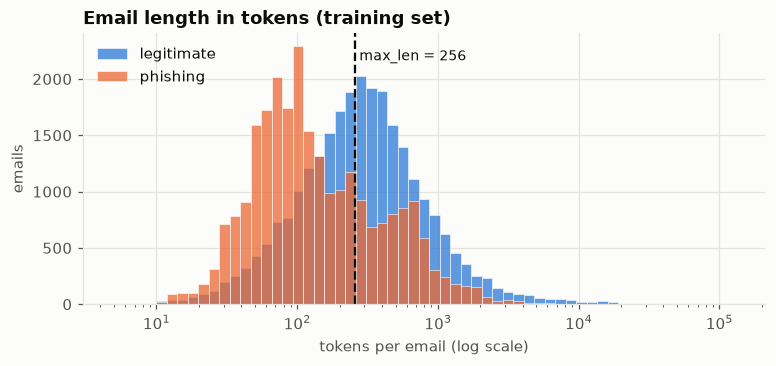

In [11]:
train_df = splits["train"].reset_index(drop=True)
val_df   = splits["val"].reset_index(drop=True)
test_df  = splits["test"].reset_index(drop=True)
if SMALL_RUN:
    train_df = train_df.sample(2000, random_state=SEED).reset_index(drop=True)
    val_df   = val_df.sample(500, random_state=SEED).reset_index(drop=True)
    test_df  = test_df.sample(500, random_state=SEED).reset_index(drop=True)

tokenizer = AutoTokenizer.from_pretrained(CFG["model_name"])

def encode(texts, max_len=CFG["max_len"]):
    # Tokenise without truncation to get true lengths, then keep the first max_len-1 tokens + [SEP]
    full = tokenizer(list(texts), add_special_tokens=True, truncation=False, verbose=False)["input_ids"]
    lengths = np.array([len(x) for x in full])
    ids = [x if len(x) <= max_len else x[:max_len - 1] + [tokenizer.sep_token_id] for x in full]
    return ids, lengths

t0 = time.time()
enc = {name: encode(d.text) for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]}
print(f"tokenised {sum(len(v[0]) for v in enc.values()):,} emails in {time.time() - t0:.0f}s")

lengths = enc["train"][1]
length_stats = pd.DataFrame({
    "median tokens": [int(np.median(v[1])) for v in enc.values()],
    "95th pct": [int(np.percentile(v[1], 95)) for v in enc.values()],
    f"% longer than {CFG['max_len']}": [round(100 * (v[1] > CFG["max_len"]).mean(), 1) for v in enc.values()],
}, index=list(enc))
display(length_stats)

fig, ax = plt.subplots(figsize=(8, 3.2))
bins = np.logspace(np.log10(max(lengths.min(), 4)), np.log10(lengths.max()), 60)
for lbl in (0, 1):
    ax.hist(lengths[train_df.label.values == lbl], bins=bins, alpha=0.75, color=PL.CLASS_COLORS[lbl],
            label=PL.CLASS_NAMES[lbl], edgecolor=PL.SURFACE, linewidth=0.5)
ax.axvline(CFG["max_len"], color=PL.TEXT, lw=1.5, ls="--")
ax.text(CFG["max_len"] * 1.08, ax.get_ylim()[1] * 0.9, f"max_len = {CFG['max_len']}", fontsize=9, color=PL.TEXT)
ax.set_xscale("log"); ax.set_xlabel("tokens per email (log scale)"); ax.set_ylabel("emails")
ax.set_title("Email length in tokens (training set)")
ax.legend(loc="upper left")
PL.save(fig, "token_lengths")
plt.show()

**Length differs by class:** phishing emails are much shorter (most are under ~150 tokens) than legitimate ones (peak around 300). So about 41% of emails exceed the limit, and most of those are legitimate. Length is itself a weak signal, which the model can partly see through how much of the 256-token window an email fills.

Emails longer than 256 tokens are cut after their first 256 tokens. That keeps the subject and opening lines, where phishing emails usually make their demand ("your account will be suspended…"). Methods that combine the start and the end, or read long emails in chunks, could recover the rest at extra cost. The limitation is noted here and discussed with the error analysis.

### 3.4 Dataset and batching

Batches are padded **dynamically**, to the longest email in each batch rather than always to 256, which saves compute on short emails. The attention mask tells the model to ignore the padding.

In [12]:
class EmailDataset(Dataset):
    def __init__(self, ids, labels):
        self.ids, self.labels = ids, np.asarray(labels, dtype=np.int64)
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, i):
        return self.ids[i], self.labels[i]

def collate(batch):
    ids, labels = zip(*batch)
    width = max(len(x) for x in ids)
    input_ids = torch.full((len(ids), width), tokenizer.pad_token_id, dtype=torch.long)
    attention = torch.zeros((len(ids), width), dtype=torch.long)
    for i, x in enumerate(ids):
        input_ids[i, :len(x)] = torch.tensor(x)
        attention[i, :len(x)] = 1
    return input_ids, attention, torch.tensor(labels)

g = torch.Generator().manual_seed(CFG["seed"])
train_loader = DataLoader(EmailDataset(enc["train"][0], train_df.label), batch_size=CFG["batch_size"],
                          shuffle=True, collate_fn=collate, generator=g)
val_loader   = DataLoader(EmailDataset(enc["val"][0], val_df.label), batch_size=CFG["eval_batch_size"],
                          shuffle=False, collate_fn=collate)
test_loader  = DataLoader(EmailDataset(enc["test"][0], test_df.label), batch_size=CFG["eval_batch_size"],
                          shuffle=False, collate_fn=collate)
print(f"train batches/epoch: {len(train_loader):,} | val batches: {len(val_loader)} | test batches: {len(test_loader)}")

train batches/epoch: 1,624 | val batches: 87 | test batches: 87


### 3.5 Metrics, evaluation and early stopping

* **Metrics** are computed with the phishing class as positive, at a 0.5 threshold. AUC-ROC uses the probabilities directly, so it doesn't depend on any threshold.
* **Early stopping** watches the **validation loss**. We use loss rather than F1 because F1 at a fixed threshold is noisy (a handful of emails near 0.5 can swing it), while loss also rewards well-calibrated probabilities. The desktop app's threshold slider depends on the probabilities meaning something. Every improvement of more than `min_delta` saves a checkpoint. After `patience` evaluations without improvement, training stops and the best checkpoint is restored.

In [13]:
def compute_metrics(y_true, p_phish, threshold=0.5):
    y_pred = (p_phish >= threshold).astype(int)
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "auc_roc":   roc_auc_score(y_true, p_phish),
    }

@torch.no_grad()
def evaluate(model, loader):
    # Returns (mean cross-entropy loss, P(phishing) per email, true labels)
    model.eval()
    total, n, probs, labels = 0.0, 0, [], []
    for input_ids, attention, y in loader:
        input_ids, attention, y = input_ids.to(DEVICE), attention.to(DEVICE), y.to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.bfloat16, enabled=USE_BF16):
            logits = model(input_ids=input_ids, attention_mask=attention).logits
        logits = logits.float()
        total += F.cross_entropy(logits, y, reduction="sum").item()
        n += len(y)
        probs.append(torch.softmax(logits, dim=-1)[:, 1].cpu())
        labels.append(y.cpu())
    return total / n, torch.cat(probs).numpy(), torch.cat(labels).numpy()

class EarlyStopping:
    def __init__(self, patience, min_delta):
        self.patience, self.min_delta = patience, min_delta
        self.best, self.best_step, self.bad_evals = float("inf"), None, 0
    def step(self, value, step):
        # Returns True if `value` is a new best (lower is better)
        if value < self.best - self.min_delta:
            self.best, self.best_step, self.bad_evals = value, step, 0
            return True
        self.bad_evals += 1
        return False
    @property
    def should_stop(self):
        return self.bad_evals >= self.patience

A quick check of the early-stopping logic on a made-up validation-loss curve that improves, then plateaus and rises:

In [14]:
demo = EarlyStopping(patience=3, min_delta=1e-3)
fake_val_loss = [0.40, 0.25, 0.18, 0.1795, 0.19, 0.21, 0.22, 0.23]
for i, v in enumerate(fake_val_loss, start=1):
    improved = demo.step(v, step=i * 200)
    print(f"eval {i} (step {i * 200:>4}): val_loss={v:.4f}  {'new best' if improved else f'no improvement ({demo.bad_evals}/{demo.patience})'}")
    if demo.should_stop:
        print(f"-> stop at step {i * 200}; restore best from step {demo.best_step} (val_loss={demo.best:.4f})")
        break

eval 1 (step  200): val_loss=0.4000  new best
eval 2 (step  400): val_loss=0.2500  new best
eval 3 (step  600): val_loss=0.1800  new best
eval 4 (step  800): val_loss=0.1795  no improvement (1/3)
eval 5 (step 1000): val_loss=0.1900  no improvement (2/3)
eval 6 (step 1200): val_loss=0.2100  no improvement (3/3)
-> stop at step 1200; restore best from step 600 (val_loss=0.1800)


### 3.6 Training loop

A custom PyTorch loop (not the Hugging Face `Trainer`), so each step is explicit:

1. forward pass with **bf16 mixed precision** on the GPU. The loss is computed in float32.
2. backward pass, **gradient clipping** (max norm 1.0)
3. **AdamW** step, then the **linear warm-up / decay** scheduler step
4. every `eval_every` steps: evaluate on the full validation set, log train loss (averaged since the last evaluation), validation loss, accuracy, precision, recall, F1 and AUC-ROC, then run the early-stopping check

The log is written to `results/*_train_log.csv` after **every** evaluation, so a crash never loses it.

In [15]:
def train(model, train_loader, val_loader, cfg, ckpt_dir, log_csv):
    no_decay = ("bias", "LayerNorm.weight")
    groups = [
        {"params": [p for n, p in model.named_parameters() if not n.endswith(no_decay)], "weight_decay": cfg["weight_decay"]},
        {"params": [p for n, p in model.named_parameters() if n.endswith(no_decay)], "weight_decay": 0.0},
    ]
    optimizer = torch.optim.AdamW(groups, lr=cfg["lr"])
    total_steps = cfg["max_epochs"] * len(train_loader)
    scheduler = get_linear_schedule_with_warmup(optimizer, int(cfg["warmup_frac"] * total_steps), total_steps)
    stopper = EarlyStopping(cfg["patience"], cfg["min_delta"])

    console = []
    def log(line=""):
        print(line); console.append(line)

    history, step, run_loss, run_n = [], 0, 0.0, 0
    stopped_early, t0 = False, time.time()
    log(f"{total_steps:,} optimiser steps max ({cfg['max_epochs']} epochs x {len(train_loader):,}), "
          f"validation every {cfg['eval_every']} steps\n")
    log(f"{'step':>6} {'epoch':>6} {'train_loss':>10} {'val_loss':>9} {'acc':>7} {'prec':>7} {'rec':>7} {'f1':>7} {'auc':>7}  {'min':>5}")

    for epoch in range(cfg["max_epochs"]):
        model.train()
        for input_ids, attention, y in train_loader:
            input_ids, attention, y = input_ids.to(DEVICE), attention.to(DEVICE), y.to(DEVICE)
            with torch.autocast(device_type=DEVICE.type, dtype=torch.bfloat16, enabled=USE_BF16):
                logits = model(input_ids=input_ids, attention_mask=attention).logits
            loss = F.cross_entropy(logits.float(), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            step += 1
            run_loss += loss.item() * len(y); run_n += len(y)

            if step % cfg["eval_every"] == 0 or step == total_steps:
                val_loss, p, yv = evaluate(model, val_loader)
                m = compute_metrics(yv, p)
                improved = stopper.step(val_loss, step)
                if improved:
                    model.save_pretrained(ckpt_dir)
                    tokenizer.save_pretrained(ckpt_dir)
                history.append({"step": step, "epoch": round(step / len(train_loader), 3),
                                "lr": scheduler.get_last_lr()[0], "train_loss": run_loss / run_n,
                                "val_loss": val_loss, **m, "best_so_far": improved,
                                "minutes": round((time.time() - t0) / 60, 2)})
                pd.DataFrame(history).to_csv(log_csv, index=False)
                h = history[-1]
                log(f"{step:>6} {h['epoch']:>6.2f} {h['train_loss']:>10.4f} {val_loss:>9.4f} {m['accuracy']:>7.4f} "
                      f"{m['precision']:>7.4f} {m['recall']:>7.4f} {m['f1']:>7.4f} {m['auc_roc']:>7.4f}  "
                      f"{h['minutes']:>5.1f}{'  * saved' if improved else ''}")
                run_loss, run_n = 0.0, 0
                model.train()
                if stopper.should_stop:
                    stopped_early = True
                    break
        if stopped_early:
            break

    info = {"stopped_early": stopped_early, "last_step": step, "best_step": stopper.best_step,
            "best_val_loss": stopper.best, "total_steps_planned": total_steps,
            "train_minutes": round((time.time() - t0) / 60, 1), "evaluations": len(history),
            "device": torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "cpu", "config": cfg}
    if stopped_early:
        log(f"\nEARLY STOPPING triggered at step {step}: val loss did not improve by > {cfg['min_delta']} "
              f"for {cfg['patience']} evaluations. Best was step {stopper.best_step} (val loss {stopper.best:.4f}).")
    else:
        log(f"\nFinished all {total_steps} steps without early stopping. Best step {stopper.best_step} "
              f"(val loss {stopper.best:.4f}).")
    info["console"] = console
    return pd.DataFrame(history), info

### 3.7 Run training

In [16]:
if RETRAIN or not (CKPT_DIR / "config.json").exists():
    set_seed(CFG["seed"])
    model = AutoModelForSequenceClassification.from_pretrained(CFG["model_name"], num_labels=2).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"{CFG['model_name']}: {n_params / 1e6:.1f}M parameters, all trainable\n")
    history, run_info = train(model, train_loader, val_loader, CFG, CKPT_DIR, LOG_CSV)
    (CKPT_DIR / "train_config.json").write_text(json.dumps(
        {**CFG, "best_step": run_info["best_step"], "label_names": ["legitimate", "phishing"]}, indent=2))
    INFO_JSON.write_text(json.dumps(run_info, indent=2))
else:
    history, run_info = pd.read_csv(LOG_CSV), json.loads(INFO_JSON.read_text())
    print(f"RETRAIN=False: reusing the checkpoint and log of a previous run ({run_info['train_minutes']} min). "
          f"Its training output:\n")
    print("\n".join(run_info.get("console", [])))

RETRAIN=False: reusing the checkpoint and log of a previous run (3.5 min). Its training output:

4,872 optimiser steps max (3 epochs x 1,624), validation every 200 steps

  step  epoch train_loss  val_loss     acc    prec     rec      f1     auc    min
   200   0.12     0.3884    0.1029  0.9655  0.9642  0.9652  0.9647  0.9946    0.6  * saved
   400   0.25     0.1006    0.0783  0.9738  0.9577  0.9901  0.9736  0.9976    1.0  * saved
   600   0.37     0.0761    0.0595  0.9797  0.9828  0.9755  0.9791  0.9979    1.4  * saved
   800   0.49     0.0601    0.0529  0.9837  0.9901  0.9763  0.9831  0.9988    1.7  * saved
  1000   0.62     0.0535    0.0502  0.9846  0.9751  0.9937  0.9843  0.9992    2.1  * saved
  1200   0.74     0.0481    0.0387  0.9879  0.9906  0.9846  0.9875  0.9992    2.5  * saved
  1400   0.86     0.0375    0.0497  0.9860  0.9948  0.9765  0.9855  0.9993    2.8
  1600   0.98     0.0467    0.0534  0.9854  0.9731  0.9976  0.9852  0.9994    3.2
  1800   1.11     0.0213    0.0429  0

### 3.8 Training log

One row per validation check. ★ marks each new best validation loss, where a checkpoint was saved. The same table is in `results/distilbert_train_log.csv`. Section 4 plots these curves.

In [17]:
log_view = history.copy()
log_view["best_so_far"] = log_view["best_so_far"].map({True: "★", False: ""})
metric_cols = ["train_loss", "val_loss", "accuracy", "precision", "recall", "f1", "auc_roc"]
display(log_view.style
        .format({**{c: "{:.4f}" for c in metric_cols}, "lr": "{:.2e}", "epoch": "{:.2f}", "minutes": "{:.1f}"})
        .apply(lambda r: ["background-color: #e8f0fb" if r.step == run_info["best_step"] else "" for _ in r], axis=1)
        .hide(axis="index"))
summary = {k: run_info[k] for k in ("stopped_early", "best_step", "last_step", "total_steps_planned",
                                    "evaluations", "train_minutes", "device")}
summary["best_val_loss"] = round(run_info["best_val_loss"], 4)
pd.Series(summary, name="run").to_frame()

step,epoch,lr,train_loss,val_loss,accuracy,precision,recall,f1,auc_roc,best_so_far,minutes
200,0.12,1.37e-05,0.3884,0.1029,0.9655,0.9642,0.9652,0.9647,0.9946,★,0.6
400,0.25,1.95e-05,0.1006,0.0783,0.9738,0.9577,0.9901,0.9736,0.9976,★,1.0
600,0.37,1.87e-05,0.0761,0.0595,0.9797,0.9828,0.9755,0.9791,0.9979,★,1.4
800,0.49,1.78e-05,0.0601,0.0529,0.9837,0.9901,0.9763,0.9831,0.9988,★,1.7
1000,0.62,1.69e-05,0.0535,0.0502,0.9846,0.9751,0.9937,0.9843,0.9992,★,2.1
1200,0.74,1.60e-05,0.0481,0.0387,0.9879,0.9906,0.9846,0.9875,0.9992,★,2.5
1400,0.86,1.52e-05,0.0375,0.0497,0.9860,0.9948,0.9765,0.9855,0.9993,,2.8
1600,0.98,1.43e-05,0.0467,0.0534,0.9854,0.9731,0.9976,0.9852,0.9994,,3.2
1800,1.11,1.34e-05,0.0213,0.0429,0.9892,0.9920,0.9858,0.9889,0.9995,,3.5


,run
stopped_early,True
best_step,1200
last_step,1800
total_steps_planned,4872
evaluations,9
train_minutes,3.5
device,NVIDIA GeForce RTX 5070
best_val_loss,0.0387


### 3.9 Restore the best checkpoint

The weights at the end of training are **not** the best ones: early stopping only triggers `patience` evaluations after the best. We reload the saved best checkpoint from disk and re-evaluate on validation. The loss must match the logged best, which proves the right weights were restored.

In [18]:
model = AutoModelForSequenceClassification.from_pretrained(CKPT_DIR).to(DEVICE)
val_loss_restored, val_probs, val_labels = evaluate(model, val_loader)
print(f"restored checkpoint from step {run_info['best_step']}: val loss {val_loss_restored:.4f} "
      f"(logged best {run_info['best_val_loss']:.4f})")
assert abs(val_loss_restored - run_info["best_val_loss"]) < 5e-3, "restored weights do not match the best checkpoint"
pd.Series(compute_metrics(val_labels, val_probs), name="validation (best checkpoint)").to_frame().T.round(4)

restored checkpoint from step 1200: val loss 0.0387 (logged best 0.0387)


,accuracy,precision,recall,f1,auc_roc
validation (best checkpoint),0.9879,0.9906,0.9846,0.9875,0.9992


## 4. Evaluation

### 4.1 Training curves

From the log in section 3.8. The dashed line marks the restored best checkpoint, and the dotted line marks where early stopping ended training. The train loss is averaged over the 200 steps before each check. The validation loss is measured on the full validation set.

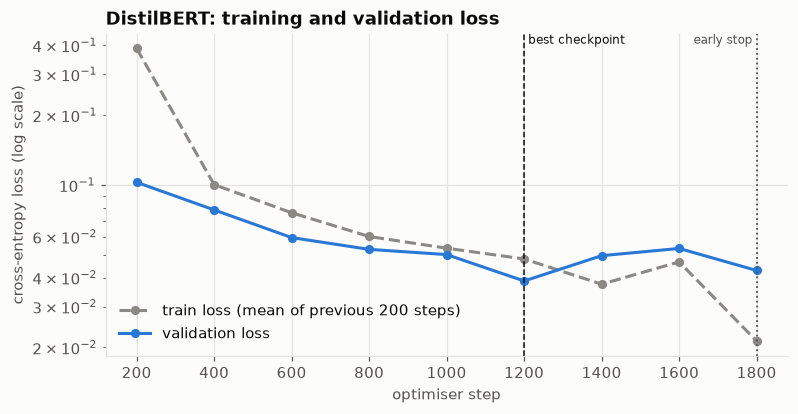

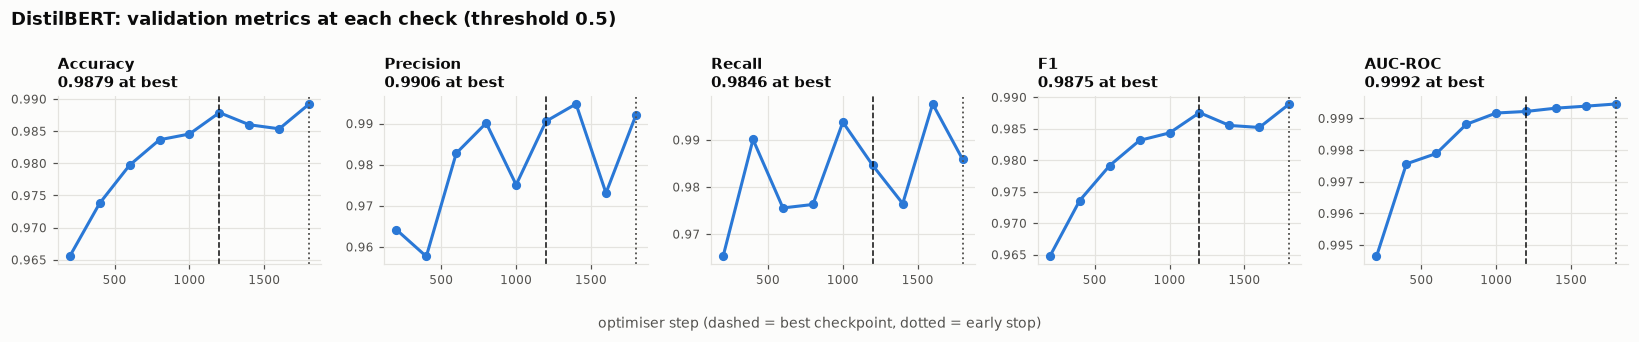

In [19]:
from sklearn.metrics import (roc_curve, precision_recall_curve, average_precision_score,
                             confusion_matrix, classification_report)

TRAIN_GREY = "#8a8984"
h, best_step, last_step = history, run_info["best_step"], run_info["last_step"]

def mark_steps(ax, label=True):
    ax.axvline(best_step, color=PL.TEXT, ls="--", lw=1)
    if run_info["stopped_early"]:
        ax.axvline(last_step, color=PL.MUTED, ls=":", lw=1.2)
    if label:
        ymax = ax.get_ylim()[1]
        ax.text(best_step, ymax, " best checkpoint", va="top", ha="left", fontsize=8, color=PL.TEXT)
        if run_info["stopped_early"]:
            ax.text(last_step, ymax, "early stop ", va="top", ha="right", fontsize=8, color=PL.MUTED)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(h.step, h.train_loss, color=TRAIN_GREY, marker="o", ms=5, ls="--", label="train loss (mean of previous 200 steps)")
ax.plot(h.step, h.val_loss, color=PL.MODEL_COLORS["distilbert"], marker="o", ms=5, label="validation loss")
ax.set_yscale("log")
ax.set_xlabel("optimiser step"); ax.set_ylabel("cross-entropy loss (log scale)")
ax.set_title("DistilBERT: training and validation loss")
mark_steps(ax)
ax.legend(loc="lower left")
PL.save(fig, "distilbert_loss_curves")
plt.show()

metrics = [("accuracy", "Accuracy"), ("precision", "Precision"), ("recall", "Recall"), ("f1", "F1"), ("auc_roc", "AUC-ROC")]
fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharex=True)
for ax, (col, title) in zip(axes, metrics):
    ax.plot(h.step, h[col], color=PL.MODEL_COLORS["distilbert"], marker="o", ms=5)
    b = h.loc[h.step == best_step, col].iloc[0]
    ax.set_title(f"{title}\n{b:.4f} at best", fontsize=10)
    ax.tick_params(labelsize=8)
    mark_steps(ax, label=False)
fig.supxlabel("optimiser step (dashed = best checkpoint, dotted = early stop)", fontsize=9, color=PL.MUTED)
fig.suptitle("DistilBERT: validation metrics at each check (threshold 0.5)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
PL.save(fig, "distilbert_val_metrics")
plt.show()

**Reading the curves.**
* Validation loss falls steeply in the first ~600 steps (about the first third of an epoch), then keeps improving slowly until step 1200.
* After that the **train loss keeps dropping (0.048 → 0.021) while the validation loss rises (0.039 → 0.043–0.053)**. That gap is the start of overfitting: the model gets more confident on emails it has already seen, without getting better on new ones. Early stopping caught it after three checks without improvement.
* The metrics barely change after step 1000, which is why early stopping watches the loss rather than a thresholded metric such as F1. Loss still notices the model becoming overconfident when F1 no longer moves.

### 4.2 Test set results

The test set is scored **once**, with the restored best checkpoint and the default threshold of 0.5. No decision so far (cleaning rules, hyperparameters, which checkpoint to keep) looked at the test set. So these numbers are an honest estimate of performance on unseen emails from the same sources.

In [20]:
test_loss, test_probs, test_labels = evaluate(model, test_loader)
pred_df = test_df[["id", "source", "subject", "body", "label"]].copy()
pred_df["prob_phishing"] = test_probs
pred_df["pred"] = (test_probs >= 0.5).astype(int)
assert (pred_df.label.values == test_labels).all()
pred_df[["id", "label", "prob_phishing"]].to_csv(ROOT / "results" / f"{TAG}_test_predictions.csv", index=False)

def summarise(y, p, threshold=0.5):
    return {**compute_metrics(y, p, threshold), "avg_precision": average_precision_score(y, p)}

test_metrics = {"DistilBERT": {"loss": test_loss, **summarise(test_labels, test_probs)}}
display(pd.DataFrame(test_metrics).T.round(4))
print(classification_report(test_labels, pred_df.pred, target_names=["legitimate", "phishing"], digits=4))

,loss,accuracy,precision,recall,f1,auc_roc,avg_precision
DistilBERT,0.0352,0.9892,0.9915,0.9864,0.9889,0.9994,0.9994


              precision    recall  f1-score   support

  legitimate     0.9871    0.9919    0.9895      5698
    phishing     0.9915    0.9864    0.9889      5438

    accuracy                         0.9892     11136
   macro avg     0.9893    0.9892    0.9892     11136
weighted avg     0.9892    0.9892    0.9892     11136



### 4.3 ROC, precision-recall and confusion matrices

These functions are applied to every model, so DistilBERT and the baseline get identical plots. The insets zoom into the top-left (ROC) and top-right (PR) corners, where good models differ.

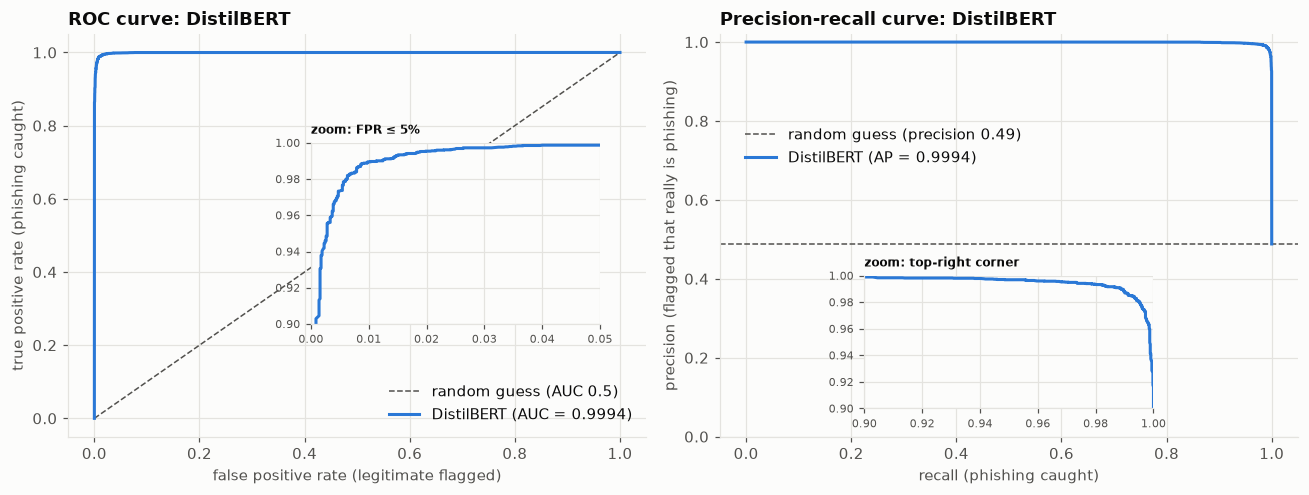

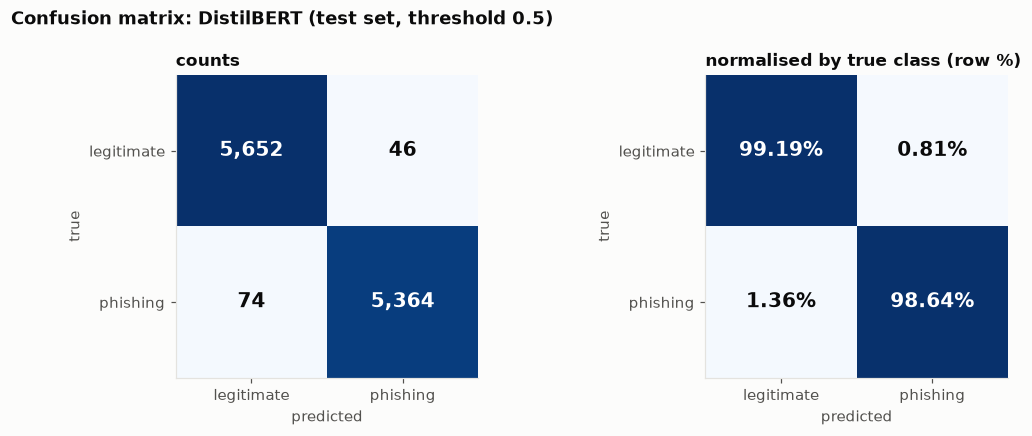

DistilBERT: 46 legitimate emails wrongly flagged (FPR 0.81%), 74 phishing emails missed (FNR 1.36%), out of 11,136


In [21]:
def plot_roc_pr(name, y, p, color, prefix):
    fpr, tpr, _ = roc_curve(y, p)
    prec, rec, _ = precision_recall_curve(y, p)
    auc, ap = roc_auc_score(y, p), average_precision_score(y, p)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6))

    a1.plot([0, 1], [0, 1], ls="--", color=PL.MUTED, lw=1, label="random guess (AUC 0.5)")
    a1.plot(fpr, tpr, color=color, label=f"{name} (AUC = {auc:.4f})")
    a1.set_xlabel("false positive rate (legitimate flagged)"); a1.set_ylabel("true positive rate (phishing caught)")
    a1.set_title(f"ROC curve: {name}"); a1.legend(loc="lower right")
    ins = a1.inset_axes([0.42, 0.28, 0.5, 0.45])
    ins.plot(fpr, tpr, color=color); ins.set_xlim(0, 0.05); ins.set_ylim(0.90, 1.0)
    ins.set_title("zoom: FPR ≤ 5%", fontsize=8); ins.tick_params(labelsize=7)

    prevalence = np.mean(y)
    a2.axhline(prevalence, ls="--", color=PL.MUTED, lw=1, label=f"random guess (precision {prevalence:.2f})")
    a2.plot(rec, prec, color=color, label=f"{name} (AP = {ap:.4f})")
    a2.set_xlabel("recall (phishing caught)"); a2.set_ylabel("precision (flagged that really is phishing)")
    a2.set_title(f"Precision-recall curve: {name}"); a2.legend(loc="center left", bbox_to_anchor=(0.02, 0.72))
    a2.set_ylim(0, 1.02)
    ins = a2.inset_axes([0.25, 0.07, 0.5, 0.33])       # below the random-guess line
    ins.plot(rec, prec, color=color); ins.set_xlim(0.90, 1.0); ins.set_ylim(0.90, 1.0)
    ins.set_title("zoom: top-right corner", fontsize=8); ins.tick_params(labelsize=7)
    fig.tight_layout()
    PL.save(fig, f"{prefix}_roc_pr")
    plt.show()

def plot_confusion(name, y, p, prefix, threshold=0.5):
    cm = confusion_matrix(y, (p >= threshold).astype(int), labels=[0, 1])
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    names = ["legitimate", "phishing"]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, mat, title, fmt in [(axes[0], cm, "counts", lambda v: f"{v:,}"),
                                (axes[1], cm_norm, "normalised by true class (row %)", lambda v: f"{100 * v:.2f}%")]:
        ax.imshow(mat, cmap="Blues", vmin=0, vmax=mat.max())
        ax.grid(False)
        for i in range(2):
            for j in range(2):
                dark = mat[i, j] > 0.55 * mat.max()
                ax.text(j, i, fmt(mat[i, j]), ha="center", va="center", fontsize=13,
                        color="white" if dark else PL.TEXT, fontweight="bold")
        ax.set_xticks([0, 1], names); ax.set_yticks([0, 1], names)
        ax.set_xlabel("predicted"); ax.set_ylabel("true")
        ax.set_title(title, fontsize=11)
    fig.suptitle(f"Confusion matrix: {name} (test set, threshold {threshold})", x=0.01, ha="left", fontweight="bold")
    fig.tight_layout()
    PL.save(fig, f"{prefix}_confusion")
    plt.show()
    tn, fp, fn, tp = cm.ravel()
    print(f"{name}: {fp} legitimate emails wrongly flagged (FPR {fp / (fp + tn):.2%}), "
          f"{fn} phishing emails missed (FNR {fn / (fn + tp):.2%}), out of {cm.sum():,}")

plot_roc_pr("DistilBERT", test_labels, test_probs, PL.MODEL_COLORS["distilbert"], "distilbert")
plot_confusion("DistilBERT", test_labels, test_probs, "distilbert")

### 4.4 How confident is the model?

The distribution of predicted probabilities, split by true class. A well-separated model puts almost all legitimate mail near 0 and almost all phishing near 1. The emails in between are the ones where the app's threshold slider changes the verdict.

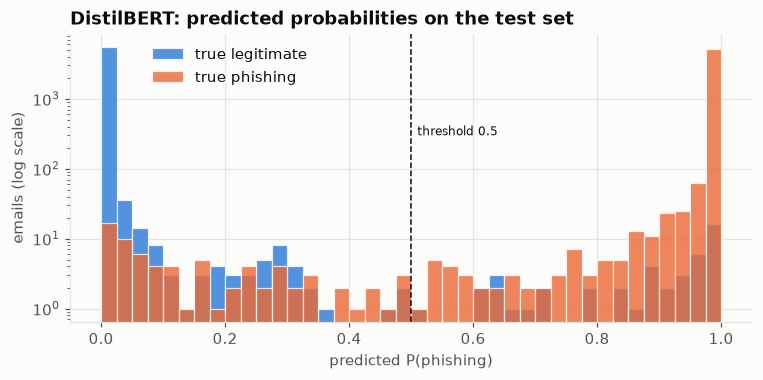

1.5% of test emails get a probability between 0.1 and 0.9 (the model is 'unsure')


In [22]:
fig, ax = plt.subplots(figsize=(8, 3.4))
bins = np.linspace(0, 1, 41)
for lbl in (0, 1):
    ax.hist(test_probs[test_labels == lbl], bins=bins, color=PL.CLASS_COLORS[lbl], alpha=0.8,
            label=f"true {PL.CLASS_NAMES[lbl]}", edgecolor=PL.SURFACE, linewidth=0.8)
ax.set_yscale("log")
ax.axvline(0.5, color=PL.TEXT, ls="--", lw=1)
ax.text(0.51, 300, "threshold 0.5", fontsize=8)
ax.set_xlabel("predicted P(phishing)"); ax.set_ylabel("emails (log scale)")
ax.set_title("DistilBERT: predicted probabilities on the test set")
ax.legend(loc="upper left", bbox_to_anchor=(0.1, 1.0))
PL.save(fig, "distilbert_prob_hist")
plt.show()

unsure = ((test_probs > 0.1) & (test_probs < 0.9)).mean()
print(f"{100 * unsure:.1f}% of test emails get a probability between 0.1 and 0.9 (the model is 'unsure')")

### 4.5 Performance per source corpus

This is the leakage check promised in section 2.4. Two sources are 100% phishing (Nazario, Nigerian_Fraud), so a model could score well there just by recognising the corpus. The real test is the **mixed sources** (CEAS_08, Enron, SpamAssasin, Ling), where legitimate and malicious mail share the same era and mail system. For single-class sources only the error rate on that one class is defined.

,n,legitimate,phishing,accuracy,f1,auc_roc,FPR (legit flagged),FNR (phishing missed),errors
source,,,,,,,,,
CEAS_08,4910,2564,2346,0.9959,0.9958,0.9999,0.70%,0.09%,20
Enron,4247,2163,2084,0.9838,0.9833,0.9989,0.79%,2.50%,69
SpamAssasin,842,611,231,0.9762,0.9565,0.9976,1.47%,4.76%,20
Nigerian_Fraud,481,0,481,1.0000,n/a,n/a,n/a,0.00%,0
Ling,428,360,68,0.9907,0.9706,0.9985,0.56%,2.94%,4
Nazario,228,0,228,0.9693,n/a,n/a,n/a,3.07%,7


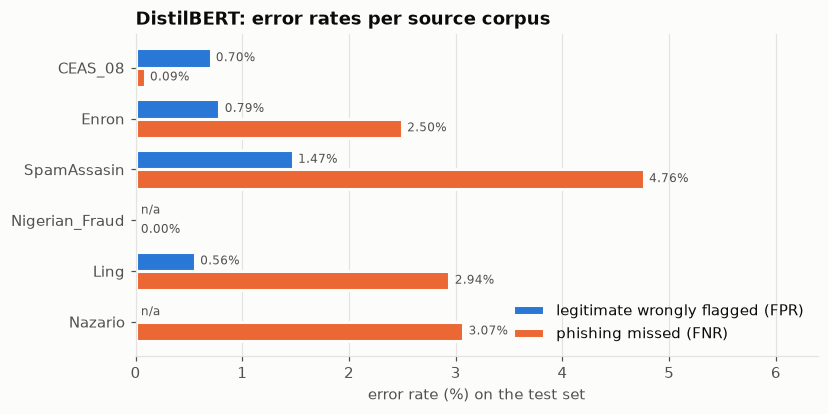

In [23]:
def per_source(df, prob_col="prob_phishing", threshold=0.5):
    rows = []
    for src, g in df.groupby("source"):
        y, p = g.label.values, g[prob_col].values
        yp = (p >= threshold).astype(int)
        n0, n1 = (y == 0).sum(), (y == 1).sum()
        fp, fn = ((yp == 1) & (y == 0)).sum(), ((yp == 0) & (y == 1)).sum()
        both = n0 > 0 and n1 > 0
        rows.append({"source": src, "n": len(g), "legitimate": n0, "phishing": n1,
                     "accuracy": (yp == y).mean(),
                     "f1": f1_score(y, yp) if both else np.nan,
                     "auc_roc": roc_auc_score(y, p) if both else np.nan,
                     "FPR (legit flagged)": fp / n0 if n0 else np.nan,
                     "FNR (phishing missed)": fn / n1 if n1 else np.nan,
                     "errors": fp + fn})
    return pd.DataFrame(rows).set_index("source").sort_values("n", ascending=False)

src_metrics = per_source(pred_df)
src_metrics.to_csv(ROOT / "results" / f"{TAG}_test_per_source.csv")
display(src_metrics.style.format({"accuracy": "{:.4f}", "f1": "{:.4f}", "auc_roc": "{:.4f}",
                                  "FPR (legit flagged)": "{:.2%}", "FNR (phishing missed)": "{:.2%}"}, na_rep="n/a"))

order = src_metrics.index[::-1]
fig, ax = plt.subplots(figsize=(8, 3.8))
yy = np.arange(len(order)); hgt = 0.38
fpr_v = 100 * src_metrics.loc[order, "FPR (legit flagged)"]
fnr_v = 100 * src_metrics.loc[order, "FNR (phishing missed)"]
ax.barh(yy + hgt / 2, fpr_v.fillna(0), height=hgt, color=PL.LEGIT, edgecolor=PL.SURFACE, linewidth=2,
        label="legitimate wrongly flagged (FPR)")
ax.barh(yy - hgt / 2, fnr_v.fillna(0), height=hgt, color=PL.PHISH, edgecolor=PL.SURFACE, linewidth=2,
        label="phishing missed (FNR)")
for i, (a, b) in enumerate(zip(fpr_v, fnr_v)):
    ax.text((0 if np.isnan(a) else a) + 0.05, i + hgt / 2, "n/a" if np.isnan(a) else f"{a:.2f}%", va="center", fontsize=8, color=PL.MUTED)
    ax.text((0 if np.isnan(b) else b) + 0.05, i - hgt / 2, "n/a" if np.isnan(b) else f"{b:.2f}%", va="center", fontsize=8, color=PL.MUTED)
ax.set_yticks(yy, order)
ax.set_xlabel("error rate (%) on the test set")
ax.set_title("DistilBERT: error rates per source corpus")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, max(np.nanmax(fpr_v), np.nanmax(fnr_v)) * 1.3 + 0.2)
ax.legend(loc="lower right")
PL.save(fig, "distilbert_per_source")
plt.show()

**Reading the per-source results.**
* **The model is not just recognising the corpus.** On the four *mixed* sources, where it has to separate legitimate from malicious mail from the same era and mail system, accuracy stays between **97.6% and 99.6%**, with AUC ≥ 0.997 everywhere. Section 2.4 showed that knowing only the corpus is worth about 57% accuracy. The model is far beyond that on exactly the sources where corpus knowledge can't help.
* **Missed phishing (FNR) is always higher than false alarms (FPR)**. The worst is SpamAssassin: 4.8% of its spam gets through. SpamAssassin is small in training (7.6% of the data) and its spam is varied.
* **Nazario, the only true credential-phishing corpus, has a 3.1% miss rate** (7 of 228). That's higher than the spam-heavy CEAS (0.1%). Phishing is a minority inside the "malicious" class, which is a point for the real-world discussion.

### 4.6 Error analysis: false positives and false negatives

Below are the most **confident** mistakes in each direction. These are the most informative, because the model was sure and wrong. The subject and the start of the body are shown as the model saw them (after cleaning).

In [24]:
errors = pred_df[pred_df.pred != pred_df.label]
fps = errors[errors.label == 0].sort_values("prob_phishing", ascending=False)
fns = errors[errors.label == 1].sort_values("prob_phishing")
print(f"{len(errors)} errors on {len(pred_df):,} test emails: {len(fps)} false positives, {len(fns)} false negatives")
display(pd.crosstab(errors.source, errors.label.map({0: "false positive", 1: "false negative"})).rename_axis(None, axis=1))

def show_examples(df, title, n=6):
    view = df.head(n).assign(body=lambda d: d.body.str.slice(0, 260).str.replace("\n", " ") + "…")
    display(Markdown(f"**{title}**"))
    display(view[["source", "prob_phishing", "subject", "body"]].style
            .format({"prob_phishing": "{:.3f}"}).hide(axis="index")
            .set_properties(subset=["body"], **{"white-space": "pre-wrap", "text-align": "left", "min-width": "420px"})
            .set_properties(subset=["subject"], **{"text-align": "left"}))

show_examples(fps, "False positives: legitimate emails the model flagged as phishing (most confident first)")
show_examples(fns, "False negatives: phishing/spam the model let through (most confident first)")

120 errors on 11,136 test emails: 46 false positives, 74 false negatives


,false negative,false positive
source,,
CEAS_08,2,18
Enron,52,17
Ling,2,2
Nazario,7,0
SpamAssasin,11,9


**False positives: legitimate emails the model flagged as phishing (most confident first)**

source,prob_phishing,subject,body
SpamAssasin,0.997,Mail delivery failure,"This message was created automatically by mail delivery software. A message that you sent could not be delivered to all of its recipients. The following message, addressed to '[email]', failed because it has not been collected after 30 days Here is a copy of t…"
Enron,0.997,document,"change the name to get your private , free e - mail from msn hotmail at http : / / www . hotmail . com . share information about yourself , create your own public profile at http : / / profiles . msn . com . - jclres . doc…"
SpamAssasin,0.997,Failed mail: Banned or potentially offensive material,"This is a MIME-encapsulated message --==[email]==_ Content-Type: text/plain; charset=""us-ascii"" Content-Transfer-Encoding: 7bit Content-Disposition: inline Your message was not delivered to [email] This mail message contains banned or potentially offensive tex…"
Enron,0.997,your confirmation is needed,"please reply to this email message to confirm your subscription to enl - dailyupdate - txt . your email address has been entered for a subscription to the enl - dailyupdate - txt mailing list . however , your new subscription requires a confirmation that you r…"
Enron,0.996,important information about security & clickathome,"dear clickathome participant , clickathome is interested in making sure you have the latest security tools available to you . as part of the clickathome program , you may download and update norton anti - virus and blackice defender software from the clickatho…"
Enron,0.995,valentines day help,red - neck valentine ' s love poem collards is green my dog ' s name is blue and i ' m so lucky to have a sweet thang like you . yore hair is like cornsilk a - flapping in the breeze softer than old blue ' s and without all them fleas . you move like the bass …


**False negatives: phishing/spam the model let through (most confident first)**

source,prob_phishing,subject,body
Ling,0.002,junk mail : books for linguists,plurabelle books has a new catalogue of second hand and out of print books in linguistics and history of linguistics available . it contains 250 titles . please ask for your free copy of the catalogue ( please include your mailing address if you want a paper c…
Enron,0.003,fwd : pass this on ! important !,"buddy , how are you wonderful day ? do you want $ 27 , 000 ? funding is available for almost any reason . ~ you do not have to pay it back ~ ~ there are no bank fees involved ~ http : / / www . netdealsforyou . com / mailer . htm ~~~ i thank you for the email …"
Enron,0.003,virtual conference and technology showcase,"cm crossroads presents the online event of the year alm expo [year] . for the first time ever , you can attend a global developers conference and technology showcase without leaving your office . register now online alm expo [year] is a virtual conference andt…"
Enron,0.004,cox communications customer followup,"hey , been a while since we ' ve talked . whats up ? i need some advice reguarding my bank statement last week . think you could help me please ? it would be much appreciated , thanks . hope to talk to you soon , mom…"
Enron,0.004,[ ilug - social ] re : take the steps to wealth for $ 25 . do it now 26138654332222,"updated may 9 , [year] . . . read this ! you ' ll be happy you did ! a recent survey by nielsen / netratings says that "" the internet population is rapidly approaching a ' half a billion ' people ! "" so what does all this mean to you ? let ' s assume that ever…"
Enron,0.004,nymex invitation - learn power trading,power trading fundamentals : sept 15 - 16 nymex in nyc early bird discount now in effect ! nymex power delegates will learn : electricity markets overview simulated trading exercise market factors basic trading tools new york mercantile exchange financial inst…


**What the mistakes have in common**

*False positives (46 legitimate emails flagged):*
* **Automated system mail that uses phishing vocabulary.** Bounce messages ("Mail delivery failure"), subscription confirmations ("please reply to this email message to confirm your subscription"), IT notices ("urgent - to prevent loss of information … press the 'save my data' button") and security-software notices all share phishing's wording: *urgent, confirm, click, security, your account*. This is the classic false-positive problem of phishing filters. Legitimate services do ask users to act.
* **Commercial newsletters labelled legitimate** (CEAS "Simplify Your Life", a government-contracting offer). Marketing mail sits on the spam/legitimate boundary, where the label is partly a matter of opinion.
* A few look like **label noise or depend on context**, such as a joke poem forwarded between colleagues.

*False negatives (74 malicious emails missed, 52 of them from Enron):*
* **Spam that reads like business mail**: conference invitations, trading courses, industry newsletters, a book catalogue. In Enron, the *legitimate* mail is itself business mail about energy trading, so business-style spam blends in. These are spam rather than phishing, and the dataset merges the two into one label (section 2.1).
* **Short, conversational scams with no links and no urgency words**, for example a message signed "mom" asking for advice about a bank statement, or a one-line mortgage offer. Social engineering without the usual cues is the hardest case, for people as well.
* **Word-salad spam**: random text added to get past filters ("range all crown is papers . on definition …"). It works here too.

**What this means.** The errors are concentrated where the class boundary is genuinely fuzzy (marketing vs spam, automated notices vs phishing), not on obvious attacks: advance-fee fraud is caught 100% of the time. Only **1.5%** of test emails get a probability between 0.1 and 0.9 (section 4.4), so moving the threshold changes few verdicts. The model is usually confident, including when it is wrong. That matters in deployment: a confident wrong answer doesn't show up as "uncertain", so a human-review queue based only on uncertainty would miss these errors.

### 4.7 Comparison with the TF-IDF + Logistic Regression baseline

The baseline is built separately (`src/baseline.py`, see `docs/handover/02_tfidf_baseline.md`) and writes its test-set probabilities to `results/baseline_test_predictions.csv`. Here it gets exactly the same plots and per-source analysis.

In [25]:
BASELINE_CSV = ROOT / "results" / "baseline_test_predictions.csv"
if BASELINE_CSV.exists() and not SMALL_RUN:
    bl = pd.read_csv(BASELINE_CSV, dtype={"id": str})
    cmp_df = pred_df.merge(bl[["id", "prob_phishing"]].rename(columns={"prob_phishing": "prob_baseline"}), on="id", how="left")
    assert cmp_df.prob_baseline.notna().all(), "baseline predictions do not cover the same test ids"
    bl_probs = cmp_df.prob_baseline.values
    test_metrics["TF-IDF + LR"] = {"loss": np.nan, **summarise(test_labels, bl_probs)}
    display(pd.DataFrame(test_metrics).T.round(4))

    plot_roc_pr("TF-IDF + LR", test_labels, bl_probs, PL.MODEL_COLORS["tfidf_lr"], "baseline")
    plot_confusion("TF-IDF + LR", test_labels, bl_probs, "baseline")

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.4))
    for name, p, key in [("DistilBERT", test_probs, "distilbert"), ("TF-IDF + LR", bl_probs, "tfidf_lr")]:
        fpr, tpr, _ = roc_curve(test_labels, p); prec, rec, _ = precision_recall_curve(test_labels, p)
        a1.plot(fpr, tpr, color=PL.MODEL_COLORS[key], label=f"{name} (AUC {roc_auc_score(test_labels, p):.4f})")
        a2.plot(rec, prec, color=PL.MODEL_COLORS[key], label=f"{name} (AP {average_precision_score(test_labels, p):.4f})")
    a1.set_xlim(0, 0.1); a1.set_ylim(0.85, 1.0); a1.set_title("ROC (zoomed: FPR ≤ 10%)")
    a1.set_xlabel("false positive rate"); a1.set_ylabel("true positive rate"); a1.legend(loc="lower right")
    a2.set_xlim(0.85, 1.0); a2.set_ylim(0.85, 1.0); a2.set_title("Precision-recall (zoomed)")
    a2.set_xlabel("recall"); a2.set_ylabel("precision"); a2.legend(loc="lower left")
    fig.suptitle("DistilBERT vs TF-IDF baseline (test set)", x=0.01, ha="left", fontweight="bold")
    fig.tight_layout(); PL.save(fig, "comparison_roc_pr"); plt.show()

    cmp_src = per_source(cmp_df.rename(columns={"prob_phishing": "p_db"}).assign(prob_phishing=bl_probs))
    both = src_metrics[["accuracy", "FPR (legit flagged)", "FNR (phishing missed)"]].join(
        cmp_src[["accuracy", "FPR (legit flagged)", "FNR (phishing missed)"]], lsuffix=" | DistilBERT", rsuffix=" | TF-IDF")
    display(Markdown("**Per-source comparison**"), both.style.format("{:.4f}", na_rep="n/a"))
else:
    display(Markdown("> **Baseline predictions not available yet.** `results/baseline_test_predictions.csv` is produced "
                     "by `python -m src.baseline` (teammate task). Re-run this section once it exists. It will then "
                     "show the baseline's ROC, PR and confusion plots and a side-by-side comparison."))

final = pd.DataFrame(test_metrics).T
final.to_csv(ROOT / "results" / "test_metrics.csv")
display(Markdown("**Final test-set metrics** (also saved to `results/test_metrics.csv`)"), final.round(4))

> **Baseline predictions not available yet.** `results/baseline_test_predictions.csv` is produced by `python -m src.baseline` (teammate task). Re-run this section once it exists. It will then show the baseline's ROC, PR and confusion plots and a side-by-side comparison.

**Final test-set metrics** (also saved to `results/test_metrics.csv`)

,loss,accuracy,precision,recall,f1,auc_roc,avg_precision
DistilBERT,0.0352,0.9892,0.9915,0.9864,0.9889,0.9994,0.9994
